# TP 2 · Tres hipótesis sobre el dataset canónico

**Grupo 5K10-06** · Ciencia de Datos · UTN FRM · 2026

**Integrantes:** Carobolante, Alejo · Dallape, Vincenzo · Podesta, Isidro · Saini, Alejo

**Liga asignada en el TP1:** Bundesliga (Austria) — `league_id` = 80

---

### Las tres hipótesis de un vistazo

| # | Pregunta | Plantilla | Medida | Resultado | Zona | Movimientos |
|---|---|---|---|---|---|---|
| 1 | Responder | Asociación | Correlación de Pearson | 0,550 → 0,896 | Amarillo → Verde | 1 (cambiar la escala) |
| 2 | Predecir | Comparación | Separación estandarizada | 0,086 | Rojo | ninguno |
| 3 | Responder | Composición | η² (razón de correlación) | 0,284 | Verde | ninguno |

La hipótesis 3 es la que filtra por nuestra `league_id`.

El análisis exploratorio y la auditoría del dataset están resueltos en los notebooks de la práctica y no se repiten acá. Este notebook arranca donde termina aquél: eligiendo preguntas y contestándolas.

## 0 · Preparación

### Cómo se carga el dataset

La celda de abajo busca el CSV canónico en el disco y, si no lo encuentra, lo descarga.

> **Antes de entregar:** pegar en `DATA_URL` la misma URL que usan los notebooks de la práctica, para que el notebook corra en una máquina limpia sin ningún archivo al lado.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

# Dataset canónico de la materia: snapshot 260046 de sofifa (23/07/2026),
# 18.936 jugadores x 90 columnas.
DATA_URL = ""   # <-- pegar acá la URL de los notebooks de la práctica

RUTAS_LOCALES = [
    Path("fifa_snapshot.csv"),
    Path("dataset.csv"),
    Path("include/frozen/fifa_snapshot.csv"),
    Path("CienciaDatos-BaseCanonica-TPs/include/frozen/fifa_snapshot.csv"),
    Path("../CienciaDatos-BaseCanonica-TPs/include/frozen/fifa_snapshot.csv"),
]


def cargar_dataset():
    for ruta in RUTAS_LOCALES:
        if ruta.exists():
            print("Dataset local:", ruta)
            return pd.read_csv(ruta, low_memory=False)
    if DATA_URL:
        print("Descargando el dataset...")
        datos = pd.read_csv(DATA_URL, low_memory=False)
        datos.to_csv("fifa_snapshot.csv", index=False)
        print("Guardado en fifa_snapshot.csv para las próximas corridas.")
        return datos
    raise FileNotFoundError(
        "No se encontró el dataset. Poné el CSV al lado del notebook "
        "o completá DATA_URL."
    )


df = cargar_dataset()
print("Filas y columnas:", df.shape)
print("Snapshot:", df["fifa_update_date"].iloc[0])

Dataset local: include\frozen\fifa_snapshot.csv


Filas y columnas: (18936, 90)
Snapshot: 2026-07-23


### Nuestra liga

Filtramos por `league_id`, no por el nombre, como pide el enunciado.

In [2]:
LIGA_ID = 80

liga = df[df["league_id"] == LIGA_ID].copy()
print("league_id:", LIGA_ID)
print("Liga:", liga["league_name"].iloc[0], "|", liga["league_country"].iloc[0])
print("Jugadores:", len(liga), "| Clubes:", liga["club_name"].nunique())

league_id: 80
Liga: Bundesliga | Austria
Jugadores: 348 | Clubes: 12


### El semáforo y las medidas

Cada plantilla tiene **una** medida, y la medida se elige antes de ver el resultado. Los cortes se aplican sobre el valor absoluto: el signo indica dirección y se lee aparte.

| Medida | Cuándo se usa | Rojo | Amarillo | Verde |
|---|---|---|---|---|
| Separación estandarizada | Una numérica entre **dos** grupos | < 0,20 | 0,20 – 0,80 | > 0,80 |
| η² (razón de correlación) | Una numérica entre **muchos** grupos | < 0,05 | 0,05 – 0,25 | > 0,25 |
| Correlación | **Dos** numéricas | < 0,20 | 0,20 – 0,60 | > 0,60 |
| Brecha Spearman − Pearson | Detectar que la relación no es recta | < 0,05 | 0,05 – 0,15 | > 0,15 |

Con 18.936 filas casi cualquier diferencia da estadísticamente significativa. El semáforo no pregunta si el efecto existe, pregunta si es lo bastante grande como para cambiar una decisión.

In [3]:
CORTES = {
    "separacion":  (0.20, 0.80),
    "eta2":        (0.05, 0.25),
    "correlacion": (0.20, 0.60),
    "brecha":      (0.05, 0.15),
}


def zona(valor, medida):
    """Devuelve ROJO / AMARILLO / VERDE según los cortes de la medida."""
    corte_rojo, corte_verde = CORTES[medida]
    v = abs(valor)
    if v < corte_rojo:
        return "ROJO"
    if v < corte_verde:
        return "AMARILLO"
    return "VERDE"


def semaforo(etiqueta, valor, medida):
    z = zona(valor, medida)
    print(f"{etiqueta:<46s} {valor:+.3f}   ->  {z}")
    return z


def spearman(a, b):
    """Spearman es Pearson sobre los rangos. Lo calculamos así para no
    depender de scipy y que el notebook corra en cualquier máquina."""
    return a.rank().corr(b.rank())


def separacion_estandarizada(a, b):
    """d de Cohen: diferencia de medias en unidades de desvío combinado."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    s_comb = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s_comb


def eta_cuadrado(datos, numerica, grupo):
    """Proporción de la variación total de `numerica` que se explica por
    la pertenencia a cada `grupo`."""
    y = datos[numerica].astype(float)
    media_global = y.mean()
    sc_total = ((y - media_global) ** 2).sum()
    sc_entre = (
        datos.groupby(grupo, observed=True)[numerica]
        .apply(lambda s: len(s) * (s.astype(float).mean() - media_global) ** 2)
        .sum()
    )
    return sc_entre / sc_total


print("Funciones listas.")

Funciones listas.


---

# Hipótesis 1 · ¿Qué determina el valor de un jugador?

**Pregunta: responder.** Es una pregunta de negocio y termina en una conclusión sobre cómo tratar la variable.

### 1. La afirmación

> En el dataset canónico, el valor de mercado de un jugador (`value_eur`) está asociado a su valoración general (`overall`): los jugadores con mayor `overall` valen más.

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero una correlación de Pearson **alta, por encima de 0,70**, o sea verde de entrada y sin movimientos. El `overall` es el número con el que el propio juego resume a un jugador, así que debería mandar sobre el precio por encima de cualquier otro atributo. En el gráfico espero una nube que sube de manera bastante pareja, con más dispersión hacia la derecha porque los jugadores muy buenos son pocos.

Si me equivoco, apostaría a que la correlación queda algo más baja de lo que creo, cerca de 0,65, por culpa de los jugadores jóvenes de proyección, que valen mucho sin tener todavía un `overall` alto.

### 3. Cómo la mido

- **Plantilla:** asociación. La afirmación relaciona **dos variables numéricas**.
- **Medida:** correlación de Pearson entre `overall` y `value_eur`. Cortes 0,20 / 0,60.
- **Gráfico:** dispersión de `value_eur` contra `overall`.

Reporto además la correlación de Spearman para tener la **brecha Spearman − Pearson**, que es el diagnóstico de si la relación es recta o no. La brecha no reemplaza a la medida de la plantilla: sirve para elegir el movimiento si el resultado cae en amarillo.

In [4]:
# 11 jugadores tienen value_eur = 0 (sin valor publicado en la fuente).
# Se excluyen: un valor de cero no es un precio bajo, es un dato ausente.
sin_valor = (df["value_eur"] == 0).sum()
h1 = df[df["value_eur"] > 0].copy()
print(f"Excluidos por value_eur = 0: {sin_valor}   |   Quedan: {len(h1)}")

r_pearson = h1["overall"].corr(h1["value_eur"])
r_spearman = spearman(h1["overall"], h1["value_eur"])
brecha = abs(r_spearman) - abs(r_pearson)

print()
z1 = semaforo("Pearson  overall ~ value_eur", r_pearson, "correlacion")
print(f"{'Spearman overall ~ value_eur':<46s} {r_spearman:+.3f}")
semaforo("Brecha Spearman - Pearson", brecha, "brecha")

Excluidos por value_eur = 0: 11   |   Quedan: 18925

Pearson  overall ~ value_eur                   +0.550   ->  AMARILLO
Spearman overall ~ value_eur                   +0.883
Brecha Spearman - Pearson                      +0.333   ->  VERDE


'VERDE'

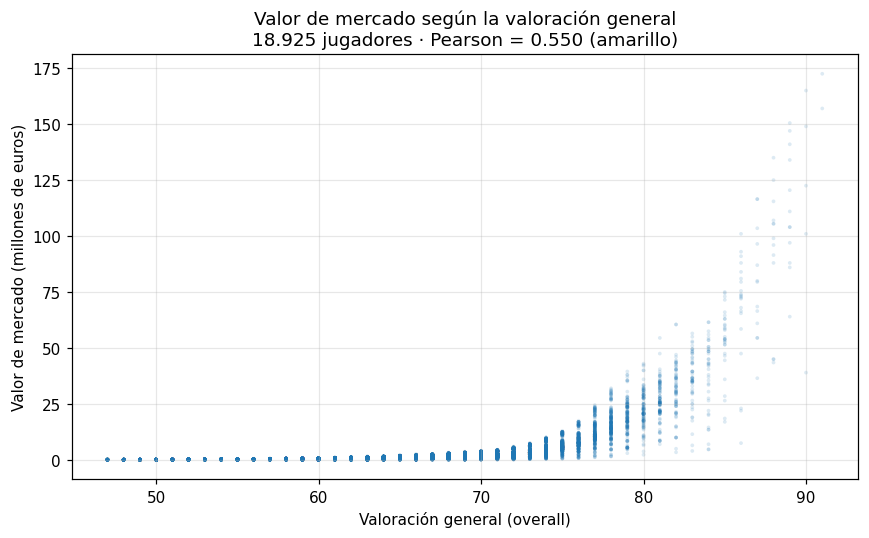

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(h1["overall"], h1["value_eur"] / 1e6, s=6, alpha=0.15,
           color="#1f77b4", edgecolors="none")
ax.set_title("Valor de mercado según la valoración general\n"
             f"18.925 jugadores · Pearson = {r_pearson:.3f} (amarillo)")
ax.set_xlabel("Valoración general (overall)")
ax.set_ylabel("Valor de mercado (millones de euros)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **Pearson** `overall` ~ `value_eur` | **+0,550** | **AMARILLO** |
| Spearman | +0,883 | — |
| Brecha Spearman − Pearson | +0,333 | por encima de 0,15 |

La correlación quedó **más baja de lo que esperaba** y cae en amarillo, así que hay que indagar.

El gráfico explica por qué. La nube no sube de forma pareja: se queda pegada al piso hasta un `overall` de 70 y recién después se despega, y a partir de 80 se dispara. No es una recta con ruido, es una curva. Pearson mide cuánto se parece la nube a una **recta**, y esta nube no lo es, así que el 0,550 subestima una relación que en realidad es muy fuerte. Spearman, que sólo mira el orden, da 0,883 y lo confirma: el orden se respeta casi perfecto, lo que falla es la forma.

### 5. Qué movimiento hice

**Cambiar la escala.** Uno solo.

El enunciado dice que ese movimiento corresponde cuando *la nube sube de forma ordenada pero curva, y la brecha entre Spearman y Pearson es grande*. Es exactamente el caso: la brecha da 0,333, muy por encima del corte de 0,15, y en el gráfico se ve el codo. No elegí entre los tres movimientos a ojo: los otros dos no aplican. No hay grupos que se despeguen, así que no hay nada que partir, y el resultado no contradice nada que sepamos, así que no hay una tercera variable que controlar.

Aplico logaritmo en base 10 al valor y vuelvo a medir.

In [6]:
h1["log_value"] = np.log10(h1["value_eur"])

r_pearson_log = h1["overall"].corr(h1["log_value"])
z1_post = semaforo("Pearson  overall ~ log10(value_eur)", r_pearson_log, "correlacion")
print(f"\nAntes del movimiento: {r_pearson:+.3f} ({z1})")
print(f"Despues del movimiento: {r_pearson_log:+.3f} ({z1_post})")

Pearson  overall ~ log10(value_eur)            +0.896   ->  VERDE

Antes del movimiento: +0.550 (AMARILLO)
Despues del movimiento: +0.896 (VERDE)


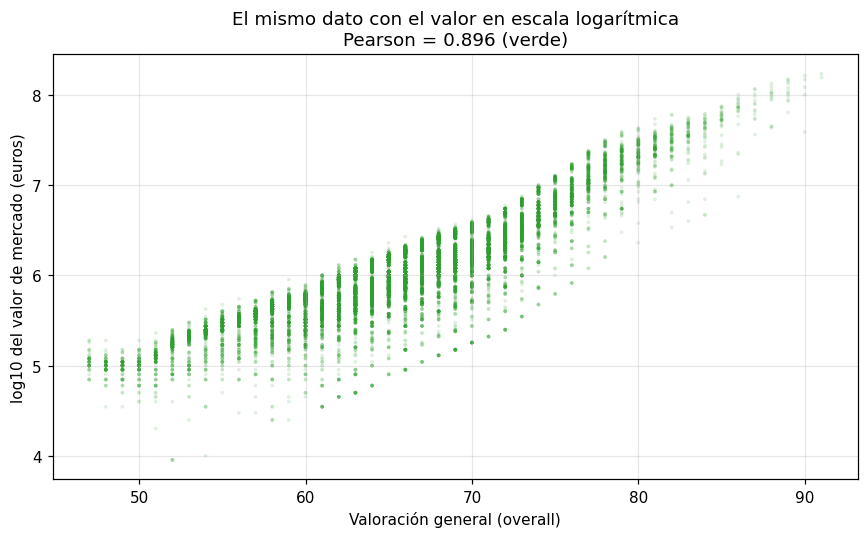

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(h1["overall"], h1["log_value"], s=6, alpha=0.15,
           color="#2ca02c", edgecolors="none")
ax.set_title("El mismo dato con el valor en escala logarítmica\n"
             f"Pearson = {r_pearson_log:.3f} (verde)")
ax.set_xlabel("Valoración general (overall)")
ax.set_ylabel("log10 del valor de mercado (euros)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Con el valor en escala logarítmica la nube se endereza y la correlación pasa de **0,550 (amarillo)** a **0,896 (verde)**. La relación siempre estuvo ahí; lo que estaba mal era la escala en la que la mirábamos.

### 6. Qué hago con eso

**`value_eur` hay que transformarla: entra al modelo en escala logarítmica, nunca cruda.**

Tres consecuencias concretas:

1. Cualquier método que asuma relaciones rectas, y la regresión lineal es el caso obvio, va a subestimar el peso del `overall` si recibe el valor en euros.
2. En escala cruda, un puñado de jugadores de más de 100 millones domina el error y aplasta a los 18.900 restantes. En logaritmo, todos pesan parecido.
3. `overall` queda confirmada como variable fuerte y se conserva. La misma lógica vale para `wage_eur` y `release_clause_eur`, que son montos de dinero con la misma forma de distribución.

---

# Hipótesis 2 · ¿La altura sirve para distinguir puestos del mediocampo?

**Pregunta: predecir.** Apunta al objetivo de la Unidad 3, que es la posición, y termina en una decisión sobre si la columna entra o no.

### 1. La afirmación

> Entre los mediocampistas defensivos (`best_position` = `CDM`) y los mediocampistas centrales (`best_position` = `CM`), la altura (`height_cm`) difiere: los CDM son más altos.

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero una separación **moderada, alrededor de 0,40 o 0,50**, o sea amarillo. El CDM juega más cerca del área propia, disputa más pelotas aéreas y suele cubrir a los delanteros centro en las jugadas paradas, así que esperaría entre dos y tres centímetros de diferencia de media. No espero verde, porque los dos son puestos de mediocampo y muchos jugadores alternan entre ambos.

En el gráfico espero dos campanas parecidas, con la de los CDM corrida un poco a la derecha.

### 3. Cómo la mido

- **Plantilla:** comparación. La afirmación compara una **numérica** entre **dos grupos**.
- **Medida:** separación estandarizada, la d de Cohen entre CDM y CM sobre `height_cm`. Cortes 0,20 / 0,80.
- **Gráfico:** histogramas superpuestos de la altura en los dos grupos.

Elegí la separación estandarizada y no la diferencia de medias en centímetros porque los centímetros no se pueden comparar contra el semáforo: hacen falta unidades de desvío.

In [8]:
cdm = df[df["best_position"] == "CDM"]["height_cm"]
cm = df[df["best_position"] == "CM"]["height_cm"]

print(f"CDM: n = {len(cdm):5d}   media = {cdm.mean():6.2f} cm   desvío = {cdm.std(ddof=1):.2f}")
print(f"CM : n = {len(cm):5d}   media = {cm.mean():6.2f} cm   desvío = {cm.std(ddof=1):.2f}")
print(f"\nDiferencia de medias: {cdm.mean() - cm.mean():.2f} cm")
print()

d_h2 = separacion_estandarizada(cdm, cm)
z2 = semaforo("Separación estandarizada CDM vs CM (altura)", d_h2, "separacion")

CDM: n =  1289   media = 180.50 cm   desvío = 5.65
CM : n =  1193   media = 180.02 cm   desvío = 5.60

Diferencia de medias: 0.48 cm

Separación estandarizada CDM vs CM (altura)    +0.086   ->  ROJO


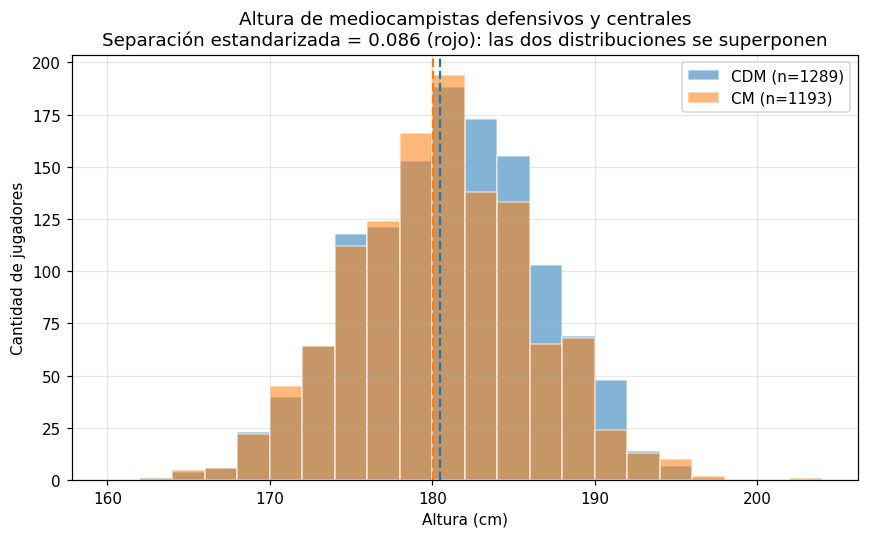

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.arange(160, 205, 2)
ax.hist(cdm, bins=bins, alpha=0.55, label=f"CDM (n={len(cdm)})",
        color="#1f77b4", edgecolor="white")
ax.hist(cm, bins=bins, alpha=0.55, label=f"CM (n={len(cm)})",
        color="#ff7f0e", edgecolor="white")
ax.axvline(cdm.mean(), color="#1f77b4", linestyle="--", linewidth=1.5)
ax.axvline(cm.mean(), color="#ff7f0e", linestyle="--", linewidth=1.5)
ax.set_title("Altura de mediocampistas defensivos y centrales\n"
             f"Separación estandarizada = {d_h2:.3f} (rojo): las dos distribuciones se superponen")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Cantidad de jugadores")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **Separación estandarizada** CDM vs CM en `height_cm` | **+0,086** | **ROJO** |

- CDM: 1.289 jugadores, media 180,50 cm
- CM: 1.193 jugadores, media 180,02 cm
- Diferencia: **0,48 cm**, menos de medio centímetro

**La hipótesis queda refutada.** Las dos líneas de media están prácticamente pegadas y los histogramas se superponen casi por completo. Media distinta hay, y con casi 2.500 jugadores seguro daría estadísticamente significativa, pero medio centímetro sobre un desvío de 5,6 cm no cambia ninguna decisión. Es justo el caso que el semáforo está para atajar.

### 5. Qué movimiento hice

**Ninguno.** El resultado es rojo y en rojo se termina: el efecto no está.

### 6. Qué hago con eso

**`height_cm` no separa el mediocampo, así que no alcanza por sí sola para el modelo de posición.**

La columna igual **se conserva**, porque el problema no es la columna sino la frontera concreta que le pedimos distinguir. Para verificarlo medimos la misma columna en otra frontera, y ahí sí funciona:

In [10]:
centrales = df[df["best_position"] == "CB"]["height_cm"]
laterales = df[df["best_position"].isin(["LB", "RB"])]["height_cm"]

d_control = separacion_estandarizada(centrales, laterales)
print(f"CB       : n = {len(centrales):5d}   media = {centrales.mean():.2f} cm")
print(f"LB / RB  : n = {len(laterales):5d}   media = {laterales.mean():.2f} cm")
print()
semaforo("Separación estandarizada CB vs laterales (altura)", d_control, "separacion")
print("\nComprobación de apoyo para el campo 6, no es la medida de la hipótesis.")

CB       : n =  3769   media = 186.97 cm
LB / RB  : n =  2067   media = 178.55 cm

Separación estandarizada CB vs laterales (altura) +1.714   ->  VERDE

Comprobación de apoyo para el campo 6, no es la medida de la hipótesis.


La misma columna que no distingue CDM de CM separa muy bien a los centrales de los laterales, con una separación de 1,71 en verde. La conclusión no es «la altura no sirve», es **«la altura sirve para unas fronteras y no para otras»**.

Decisión para la Unidad 3: `height_cm` entra al modelo, pero **no puede ser la que resuelva el mediocampo**. Para separar CDM de CM hay que apoyarse en atributos de rol, no de físico, como `defending_standing_tackle` o `mentality_interceptions`. Y si el modelo confunde esos dos puestos, ya sabemos que agregar variables de físico no lo va a arreglar.

---

# Hipótesis 3 · ¿El club explica el valor dentro de nuestra liga?

**Pregunta: responder.** Es la hipótesis que usa la liga que nos tocó en el TP1.

### 1. La afirmación

> Dentro de la Bundesliga de Austria (`league_id` = 80), el club al que pertenece un jugador (`club_name`) explica una parte apreciable de la variación de su valor de mercado (`value_eur`).

### 2. Qué espero ver

*(Escrito antes de correr nada.)*

Espero **amarillo, alrededor de 0,10 o 0,15**. La Bundesliga austríaca es una liga chica y bastante pareja: doce clubes con planteles de tamaño similar y sin las diferencias de presupuesto que hay en las ligas grandes de Europa. Esperaría que el valor de un jugador lo explique mucho más lo que el jugador es que el escudo que lleva puesto.

En el gráfico espero cajas bastante alineadas, tal vez con Salzburgo un poco por encima porque es el club que juega copas europeas.

### 3. Cómo la mido

- **Plantilla:** composición. La afirmación pregunta **cómo se reparte** la variación de una numérica entre las categorías en las que se compone la población, que acá son los doce clubes.
- **Medida:** η², la razón de correlación, que es la proporción de la variación total del valor que se explica por el club. Cortes 0,05 / 0,25.
- **Gráfico:** diagrama de cajas del valor por club, ordenado por mediana.

Uso η² y no la separación estandarizada porque los grupos son **doce, no dos**.

In [11]:
print("Jugadores en la liga:", len(liga))
print("Clubes:", liga["club_name"].nunique())
print("Jugadores con value_eur = 0:", (liga["value_eur"] == 0).sum())
print()

eta2_club = eta_cuadrado(liga, "value_eur", "club_name")
z3 = semaforo("eta² del club sobre el valor (liga 80)", eta2_club, "eta2")
print()
resumen = (liga.groupby("club_name")["value_eur"]
           .agg(jugadores="count", mediana="median", media="mean")
           .sort_values("mediana", ascending=False))
print((resumen / 1).assign(
    mediana=lambda t: (t["mediana"] / 1e6).round(3),
    media=lambda t: (t["media"] / 1e6).round(3)).to_string())
print("\n(mediana y media en millones de euros)")

Jugadores en la liga: 348
Clubes: 12
Jugadores con value_eur = 0: 0

eta² del club sobre el valor (liga 80)         +0.284   ->  VERDE

                      jugadores  mediana  media
club_name                                      
FC Red Bull Salzburg       30.0    1.850  2.150
LASK Linz                  25.0    1.700  1.793
SK Sturm Graz              28.0    1.500  1.445
SK Rapid                   32.0    1.350  1.614
Wolfsberger AC             30.0    1.100  1.121
FK Austria Wien            31.0    0.825  0.917
TSV Hartberg               29.0    0.775  0.890
Blau-Weiß Linz             30.0    0.738  0.912
WSG Tirol                  28.0    0.725  0.868
Grazer AK 1902             28.0    0.675  0.773
SC Rheindorf Altach        27.0    0.625  0.700
SV Ried                    30.0    0.538  0.699

(mediana y media en millones de euros)


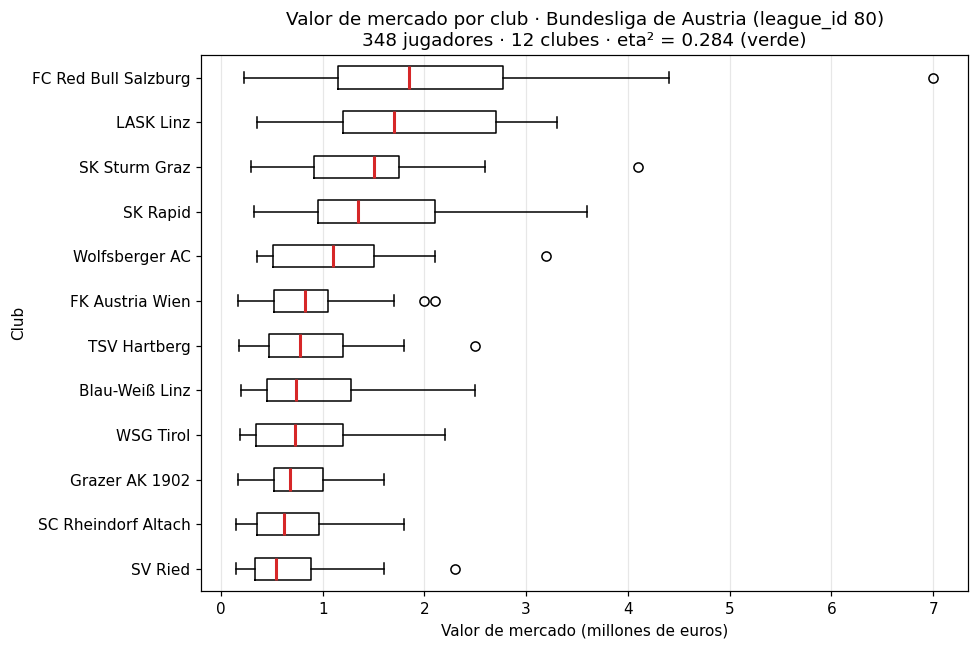

In [12]:
orden = liga.groupby("club_name")["value_eur"].median().sort_values().index.tolist()
datos_caja = [liga.loc[liga["club_name"] == club, "value_eur"] / 1e6 for club in orden]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(datos_caja, vert=False, showfliers=True,
           medianprops=dict(color="#d62728", linewidth=2))
ax.set_yticks(range(1, len(orden) + 1))
ax.set_yticklabels(orden)
ax.set_title("Valor de mercado por club · Bundesliga de Austria (league_id 80)\n"
             f"348 jugadores · 12 clubes · eta² = {eta2_club:.3f} (verde)")
ax.set_xlabel("Valor de mercado (millones de euros)")
ax.set_ylabel("Club")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### 4. Qué encontré

| Medida | Valor | Zona |
|---|---|---|
| **η²** del club sobre `value_eur`, dentro de la liga 80 | **0,284** | **VERDE** |

**La hipótesis se confirma, y más fuerte de lo que esperaba.** El club explica el 28 % de la variación del valor de mercado dentro de la liga, cuando yo esperaba la mitad de eso.

El gráfico muestra por qué. No son doce cajas alineadas: hay un escalón. Red Bull Salzburg, LASK Linz, Rapid y Sturm Graz forman un grupo claramente por encima, con medianas entre 1,3 y 1,85 millones, y abajo quedan clubes como SV Ried o Rheindorf Altach con medianas de 540 a 625 mil. Es una diferencia de más de tres veces entre las puntas, dentro de la misma liga.

La lectura futbolística es directa: son los clubes que juegan copas europeas y venden jugadores al exterior. La liga es pareja en cantidad de jugadores por plantel, pero no en dinero.

### 5. Qué movimiento hice

**Ninguno.** El resultado es verde y en verde se termina: el efecto es claro.

### 6. Qué hago con eso

**`club_name` sale del modelo de la Unidad 3, y `value_eur` no se puede usar como si fuera comparable entre clubes.**

Dos decisiones separadas:

1. **La columna del club sale.** Explica el precio, pero el objetivo de la Unidad 3 es la posición, y no hay ninguna razón para que el escudo prediga si alguien es lateral o extremo. Además son 12 categorías acá y cientos en el dataset completo, así que como variable de entrada sólo aportaría ruido y riesgo de sobreajuste.
2. **El valor arrastra el efecto del club.** Si en algún momento se usa `value_eur` como variable de entrada, hay que tener presente que un mismo jugador vale distinto según dónde juegue. Con un η² de 0,284 eso no es un detalle: para comparar jugadores entre clubes habría que normalizar el valor dentro del club, o aceptar que la variable mezcla calidad individual con poder económico del empleador.

---

# Cierre · Qué le damos al modelo de la Unidad 3

**Entran.** `overall`, `potential` y los atributos de rol, que son los que separan puestos de verdad: `defending_marking_awareness`, `defending_standing_tackle`, `mentality_interceptions`, `skill_moves` y `pace`. `height_cm` también entra, pero sabiendo que resuelve la frontera entre centrales y laterales y no la del mediocampo.

**Entra transformada.** `value_eur` sólo en escala logarítmica. En euros crudos subestima su relación con la calidad y deja que un puñado de jugadores caros domine cualquier ajuste. Lo mismo corre para `wage_eur` y `release_clause_eur`.

**Salen.** `club_name` y las columnas de identidad, que son `player_id`, `short_name`, `long_name`, `player_url` y `player_face_url`. También `league_name` y `league_country`, que son redundantes con `league_id`.

**Quedó sin resolver.** No sabemos separar CDM de CM: la altura no lo hace y todavía no probamos si los atributos defensivos alcanzan. Tampoco medimos cuánto del efecto del club sobre el valor es en realidad efecto de la calidad de los jugadores que ese club puede pagar, que es una tercera variable que empuja a las dos cosas a la vez y habría que controlar.

---

### Nota sobre los resultados

Las tres hipótesis cayeron en zonas distintas, y ninguna de las tres dio lo que esperábamos. La primera esperaba verde y dio amarillo, y el movimiento reveló que la relación era curva. La segunda esperaba amarillo y dio rojo, o sea que quedó refutada. La tercera esperaba amarillo y dio verde, con el efecto del doble de fuerte de lo previsto.

La que más información dejó fue la que falló. Descubrir que la altura no distingue el mediocampo evita que en la Unidad 3 perdamos tiempo buscando por el lado del físico un problema que es de rol.